# 🤖 Superstore – Training AI Gradient Boosting với Trajectory theo Iteration & Early Stopping
---
| Mục | Nội dung |
|---|---|
| **Dataset** | `Superstore_clean.csv` – 9,994 đơn hàng |
| **Target** | `Profit` (Lợi nhuận - Regression) |
| **Mô hình** | **Gradient Boosting Regressor** (với Early Stopping & Iteration Tracking) |
| **Split** | **80% Train / 20% Test** |
| **Monitoring** | Loss & Metrics per Iteration · Best Iteration · Early Stopping |
| **Charts** | 1. Train vs Val Metric | 2. Train vs Val Loss | 3. Actual vs Predicted | 4. Feature Importance |

> Pipeline 5 bước chuẩn hóa – Theo dõi sát sao quá trình học từng vòng lặp (Iteration) của AI.


## ⚙️ Import thư viện

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Quy tắc thiết kế biểu đồ chuẩn (User Rules)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

PALETTE = {
    'navy': '#1b365d',
    'teal': '#008080',
    'red':  '#d9534f',
    'gold': '#e8a838',
    'grey': '#6c757d',
    'dark': '#333333'
}
print("✔ Import thư viện & Cấu hình matplotlib hoàn tất!")

✔ Import thư viện & Cấu hình matplotlib hoàn tất!


---
## 📂 BƯỚC 1 – Thu thập & Tiền xử lý Dữ liệu
*(Data Collection & Preprocessing)*

In [2]:
# 1.1 Đọc dữ liệu & Kiểm tra Missing / Thống kê
DATA_PATH = '../data/Superstore_clean.csv'
df_raw = pd.read_csv(DATA_PATH)
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'], dayfirst=False)

print(f"Shape gốc: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
print(f"Khoảng thời gian: {df_raw['Order Date'].min().date()} → {df_raw['Order Date'].max().date()}")

print("\n=== BẢNG THỐNG KÊ DỮ LIỆU GỐC ===")
display(df_raw[['Sales','Discount','Quantity','Profit']].describe().round(2))

# 1.2 Thiết lập Features & Preprocessor
FEATURES     = ['Sales', 'Discount', 'Quantity', 'Category', 'Region']
TARGET       = 'Profit'
NUMERIC_FEAT = ['Sales', 'Discount', 'Quantity']
CAT_FEAT     = ['Category', 'Region']

df = df_raw[FEATURES + [TARGET, 'Order Date']].dropna().copy()
df.sort_values('Order Date', inplace=True)
df.reset_index(drop=True, inplace=True)

X = df[FEATURES].copy()
y = df[TARGET].values

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEAT),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEAT),
], remainder='drop')

X_trans = preprocessor.fit_transform(X)

ohe_feature_names = list(NUMERIC_FEAT) + list(
    preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_FEAT)
)

print("\n=== BẢNG TÓM TẮT PREPROCESSING ===")
display(pd.DataFrame({
    'Thành phần'   : ['Tổng số mẫu', 'Features số (Scaled)', 'Features phân loại (OHE)', 'Số chiều sau OHE', 'Target'],
    'Giá trị'      : [f"{len(df):,}", ', '.join(NUMERIC_FEAT), ', '.join(CAT_FEAT), len(ohe_feature_names), TARGET],
}))

Shape gốc: 9,994 dòng × 26 cột
Khoảng thời gian: 2011-01-04 → 2014-12-31

=== BẢNG THỐNG KÊ DỮ LIỆU GỐC ===


,Sales,Discount,Quantity,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,0.16,3.79,28.66
std,623.25,0.21,2.23,234.26
min,0.44,0.00,1.00,-6599.98
25%,17.28,0.00,2.00,1.73
50%,54.49,0.20,3.00,8.67
75%,209.94,0.20,5.00,29.36
max,22638.48,0.80,14.00,8399.98



=== BẢNG TÓM TẮT PREPROCESSING ===


,Thành phần,Giá trị
0,Tổng số mẫu,"9,994"
1,Features số (Scaled),"Sales, Discount, Quantity"
2,Features phân loại (OHE),"Category, Region"
3,Số chiều sau OHE,10
4,Target,Profit


---
## ✂️ BƯỚC 2 – Chia tập Train / Test (80% / 20%)
*(Train-Test Split theo thời gian)*

In [3]:
# Chia 80% Train, 20% Test (không shuffle để giữ dòng thời gian)
X_train_trans, X_test_trans, y_train, y_test = train_test_split(
    X_trans, y, test_size=0.2, shuffle=False
)

split_df = pd.DataFrame({
    'Tập dữ liệu'     : ['Train (Học)', 'Test (Thi)', 'Tổng'],
    'Số mẫu'          : [len(y_train), len(y_test), len(y)],
    'Tỷ lệ'           : ['80%', '20%', '100%'],
    'Khoảng thời gian': [
        f"{df['Order Date'].iloc[0].date()} → {df['Order Date'].iloc[len(y_train)-1].date()}",
        f"{df['Order Date'].iloc[len(y_train)].date()} → {df['Order Date'].iloc[-1].date()}",
        f"{df['Order Date'].iloc[0].date()} → {df['Order Date'].iloc[-1].date()}"
    ]
})
print("=== BẢNG CHIA DỮ LIỆU TRAIN / TEST ===")
display(split_df)

=== BẢNG CHIA DỮ LIỆU TRAIN / TEST ===


,Tập dữ liệu,Số mẫu,Tỷ lệ,Khoảng thời gian
0,Train (Học),7995,80%,2011-01-04 → 2014-07-19
1,Test (Thi),1999,20%,2014-07-19 → 2014-12-31
2,Tổng,9994,100%,2011-01-04 → 2014-12-31


---
## 🏋️ BƯỚC 3 – Huấn luyện Gradient Boosting với Early Stopping & Nhật ký Iteration
*(Model Training with Per-Iteration Tracking)*

> **Cấu hình Early Stopping**: `n_estimators=300`, `n_iter_no_change=15`, `tol=1e-4`.  
> Nếu sau 15 vòng lặp liên tiếp mà validation loss không cải thiện quá `1e-4`, mô hình sẽ **dừng sớm (Early Stopping)** để tránh overfitting.


In [4]:
MAX_ITER = 300
PATIENCE = 15

gb_model = GradientBoostingRegressor(
    n_estimators=MAX_ITER,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    n_iter_no_change=PATIENCE,
    tol=1e-4,
    validation_fraction=0.15,
    random_state=42
)

gb_model.fit(X_train_trans, y_train)

train_losses, val_losses = [], []
train_maes,   val_maes   = [], []
train_r2s,    val_r2s    = [], []

for pred_tr, pred_va in zip(gb_model.staged_predict(X_train_trans), gb_model.staged_predict(X_test_trans)):
    train_losses.append(mean_squared_error(y_train, pred_tr))
    val_losses.append(mean_squared_error(y_test, pred_va))
    train_maes.append(mean_absolute_error(y_train, pred_tr))
    val_maes.append(mean_absolute_error(y_test, pred_va))
    train_r2s.append(r2_score(y_train, pred_tr))
    val_r2s.append(r2_score(y_test, pred_va))

n_actual_iters = len(train_losses)
best_iter = int(np.argmin(val_losses)) + 1
best_val_loss = val_losses[best_iter - 1]
best_val_r2   = val_r2s[best_iter - 1]
best_val_mae  = val_maes[best_iter - 1]

print("=" * 85)
print("  📋 NHẬT KÝ HUẤN LUYỆN TỪNG VÒNG LẶP (PER-ITERATION TRAINING LOG)")
print("=" * 85)
print(f"  {'Iter':<6} | {'Train Loss (MSE)':>16} | {'Val Loss (MSE)':>16} | {'Train R²':>10} | {'Val R²':>10} | {'Val MAE ($)':>12}")
print("-" * 85)

print_iters = sorted(list(set(list(range(1, n_actual_iters + 1, 15)) + [best_iter, n_actual_iters])))

for i in print_iters:
    idx = i - 1
    marker = " 🏆 (BEST)" if i == best_iter else (" ⏹ (STOP)" if i == n_actual_iters and n_actual_iters < MAX_ITER else "")
    print(f"  {i:<6d} | {train_losses[idx]:>16.2f} | {val_losses[idx]:>16.2f} | {train_r2s[idx]*100:>9.2f}% | {val_r2s[idx]*100:>9.2f}% | ${val_maes[idx]:>11.2f}{marker}")

print("-" * 85)
print(f"✔ Tổng số vòng lặp đã chạy : {n_actual_iters} / {MAX_ITER} (Dừng sớm nhờ Early Stopping)")
print(f"🏆 Vòng lặp tốt nhất (Best Iteration): Vòng thứ {best_iter}")
print(f"   ► Best Val R²   : {best_val_r2*100:.2f}%")
print(f"   ► Best Val MAE  : ${best_val_mae:.2f}")
print(f"   ► Best Val Loss : {best_val_loss:,.2f}")

  📋 NHẬT KÝ HUẤN LUYỆN TỪNG VÒNG LẶP (PER-ITERATION TRAINING LOG)
  Iter   | Train Loss (MSE) |   Val Loss (MSE) |   Train R² |     Val R² |  Val MAE ($)
-------------------------------------------------------------------------------------
  1      |         50746.45 |         52046.92 |      7.55% |      5.00% | $      65.95
  16     |         19238.89 |         25781.06 |     64.95% |     52.94% | $      45.29
  31     |         10713.22 |         18492.49 |     80.48% |     66.25% | $      35.49
  46     |          7878.47 |         15557.97 |     85.65% |     71.60% | $      30.66
  61     |          6871.06 |         14683.34 |     87.48% |     73.20% | $      28.76
  76     |          6469.77 |         14135.19 |     88.21% |     74.20% | $      27.79
  91     |          6118.94 |         14048.98 |     88.85% |     74.36% | $      27.47
  106    |          5901.98 |         13818.73 |     89.25% |     74.78% | $      27.10
  120    |          5763.22 |         13725.27 |     89.

---
## 📊 BƯỚC 4 – Đánh giá Chi tiết & 4 Biểu đồ Trực quan hóa Matplotlib
*(Evaluation & Visualization)*

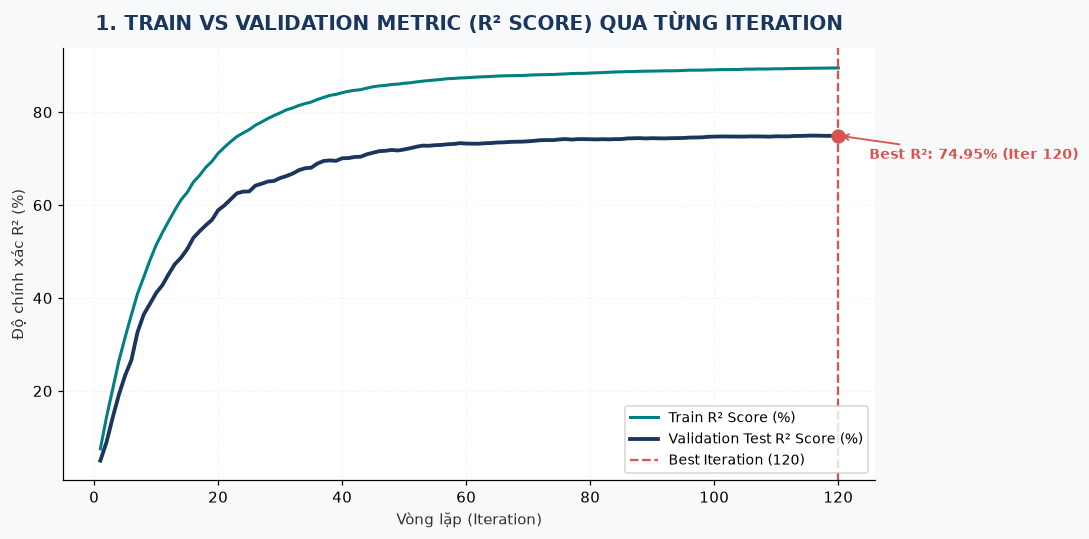

In [5]:
# 4.1 BIỂU ĐỒ 1: Train Metric vs Validation Metric theo từng Iteration (R² Score)
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#f8f9fa')
iters = range(1, n_actual_iters + 1)

ax.plot(iters, [r * 100 for r in train_r2s], color=PALETTE['teal'], lw=2, label='Train R² Score (%)')
ax.plot(iters, [r * 100 for r in val_r2s],   color=PALETTE['navy'], lw=2.5, label='Validation Test R² Score (%)')

ax.axvline(best_iter, color=PALETTE['red'], linestyle='--', lw=1.5, label=f'Best Iteration ({best_iter})')
ax.scatter(best_iter, best_val_r2 * 100, color=PALETTE['red'], s=70, zorder=5)

ax.annotate(f'Best R²: {best_val_r2*100:.2f}% (Iter {best_iter})',
            xy=(best_iter, best_val_r2 * 100), xytext=(best_iter + 5, (best_val_r2 * 100) - 5),
            arrowprops=dict(arrowstyle='->', color=PALETTE['red'], lw=1.2),
            fontweight='bold', color=PALETTE['red'], fontsize=9)

ax.set_title('1. TRAIN VS VALIDATION METRIC (R² SCORE) QUA TỪNG ITERATION',
             fontsize=13, fontweight='bold', color=PALETTE['navy'], pad=12)
ax.set_xlabel('Vòng lặp (Iteration)', fontsize=10, color=PALETTE['dark'])
ax.set_ylabel('Độ chính xác R² (%)', fontsize=10, color=PALETTE['dark'])
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2, linestyle=':')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

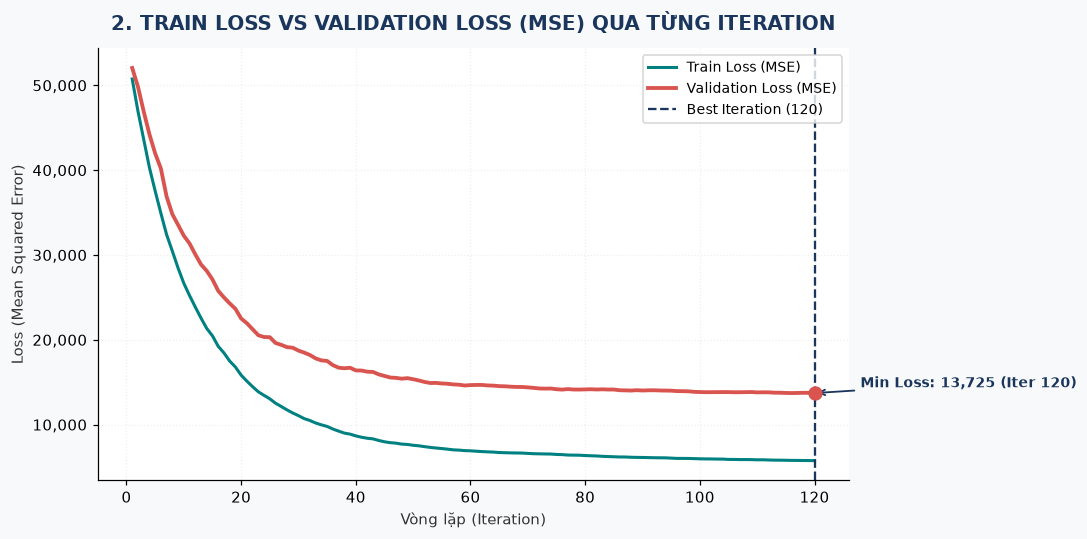

In [6]:
# 4.2 BIỂU ĐỒ 2: Train Loss vs Validation Loss theo từng Iteration (MSE Loss)
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#f8f9fa')

ax.plot(iters, train_losses, color=PALETTE['teal'], lw=2, label='Train Loss (MSE)')
ax.plot(iters, val_losses,   color=PALETTE['red'],  lw=2.5, label='Validation Loss (MSE)')

ax.axvline(best_iter, color=PALETTE['navy'], linestyle='--', lw=1.5, label=f'Best Iteration ({best_iter})')
ax.scatter(best_iter, best_val_loss, color=PALETTE['red'], s=70, zorder=5)

ax.annotate(f'Min Loss: {best_val_loss:,.0f} (Iter {best_iter})',
            xy=(best_iter, best_val_loss), xytext=(best_iter + 8, best_val_loss * 1.05),
            arrowprops=dict(arrowstyle='->', color=PALETTE['navy'], lw=1.2),
            fontweight='bold', color=PALETTE['navy'], fontsize=9)

ax.set_title('2. TRAIN LOSS VS VALIDATION LOSS (MSE) QUA TỪNG ITERATION',
             fontsize=13, fontweight='bold', color=PALETTE['navy'], pad=12)
ax.set_xlabel('Vòng lặp (Iteration)', fontsize=10, color=PALETTE['dark'])
ax.set_ylabel('Loss (Mean Squared Error)', fontsize=10, color=PALETTE['dark'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2, linestyle=':')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()

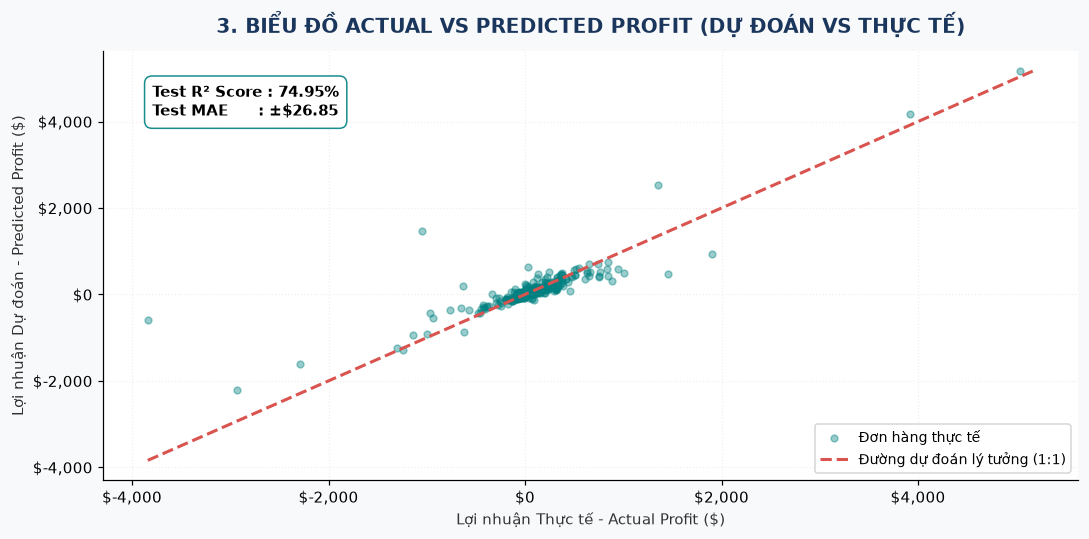

In [7]:
# 4.3 BIỂU ĐỒ 3 (REGRESSION): Actual vs Predicted Profit
y_test_pred = gb_model.predict(X_test_trans)
final_test_mae = mean_absolute_error(y_test, y_test_pred)
final_test_r2  = r2_score(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#f8f9fa')

ax.scatter(y_test, y_test_pred, alpha=0.4, color=PALETTE['teal'], s=20, label='Đơn hàng thực tế')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color=PALETTE['red'], linestyle='--', lw=2, label='Đường dự đoán lý tưởng (1:1)')

ax.text(0.05, 0.85, f'Test R² Score : {final_test_r2*100:.2f}%\nTest MAE      : ±${final_test_mae:.2f}',
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=PALETTE['teal'], alpha=0.9))

ax.set_title('3. BIỂU ĐỒ ACTUAL VS PREDICTED PROFIT (DỰ ĐOÁN VS THỰC TẾ)',
             fontsize=13, fontweight='bold', color=PALETTE['navy'], pad=12)
ax.set_xlabel('Lợi nhuận Thực tế - Actual Profit ($)', fontsize=10, color=PALETTE['dark'])
ax.set_ylabel('Lợi nhuận Dự đoán - Predicted Profit ($)', fontsize=10, color=PALETTE['dark'])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2, linestyle=':')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

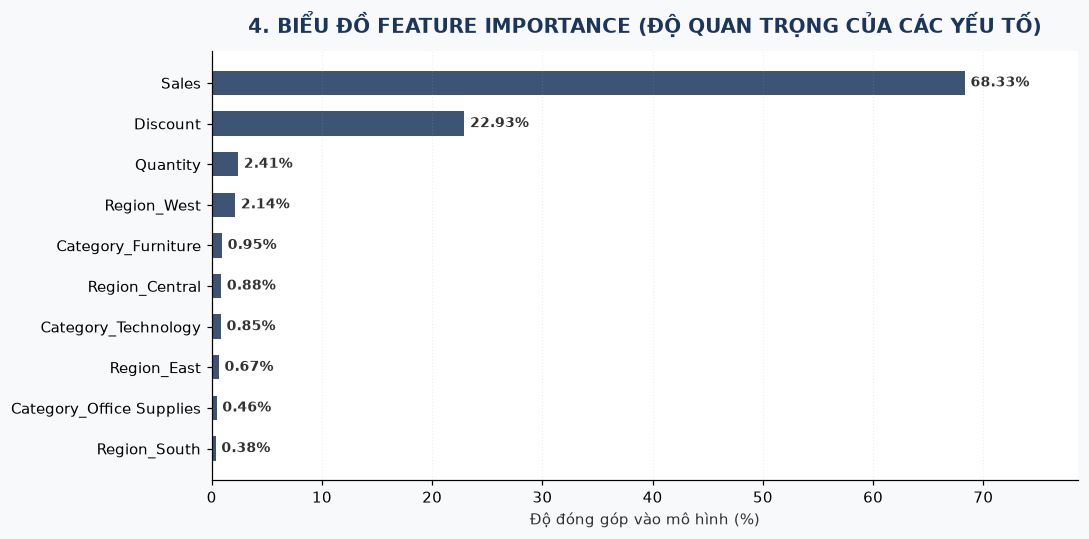

In [8]:
# 4.4 BIỂU ĐỒ 4 (REGRESSION): Feature Importance (Độ quan trọng của các biến)
importances = gb_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': ohe_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#f8f9fa')
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'] * 100, color=PALETTE['navy'], height=0.6, alpha=0.85)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2, f'{w:.2f}%',
            va='center', fontsize=9, fontweight='bold', color=PALETTE['dark'])

ax.set_title('4. BIỂU ĐỒ FEATURE IMPORTANCE (ĐỘ QUAN TRỌNG CỦA CÁC YẾU TỐ)',
             fontsize=13, fontweight='bold', color=PALETTE['navy'], pad=12)
ax.set_xlabel('Độ đóng góp vào mô hình (%)', fontsize=10, color=PALETTE['dark'])
ax.set_xlim(0, max(feat_imp_df['Importance'] * 100) * 1.15)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2, linestyle=':')
plt.tight_layout(); plt.show()

---
## 🔮 BƯỚC 5 – Dự báo Lợi nhuận 3 Tháng tiếp theo
*(Prediction & Business Forecast)*

=== BẢNG DỰ BÁO LỢI NHUẬN 3 THÁNG TỚI ===


,Tháng,Doanh thu ước tính,Lợi nhuận ước tính,Biên LN (%),So tháng trước
0,2015-01,"$100,761","$10,124",10.0%,—
1,2015-02,"$112,217","$11,303",10.1%,+11.6%
2,2015-03,"$124,975","$12,485",10.0%,+10.5%


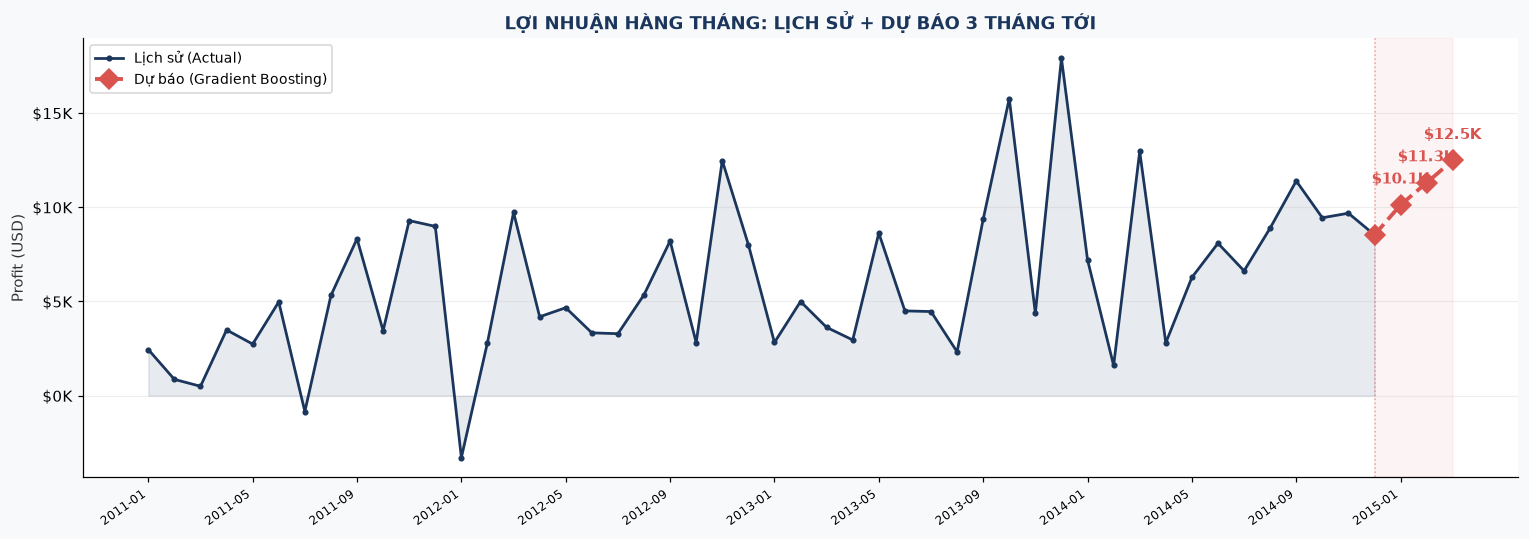

In [9]:
# Re-fit mô hình trên toàn bộ dữ liệu (Train + Test)
gb_final = GradientBoostingRegressor(
    n_estimators=best_iter,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb_final.fit(X_trans, y)

df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('YearMonth').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
monthly['YM_str'] = monthly['YearMonth'].astype(str)

growth_rate      = max(0.0, monthly['Sales'].pct_change().dropna().tail(12).mean())
base_month_sales = monthly['Sales'].iloc[-1]
cat_share = df.groupby('Category')['Sales'].sum() / df['Sales'].sum()
reg_share  = df.groupby('Region')['Sales'].sum()  / df['Sales'].sum()

last_date       = df['Order Date'].max()
future_periods  = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=3, freq='MS')
forecast_labels = [p.strftime('%Y-%m') for p in future_periods]

def forecast_month(idx):
    month_sales = base_month_sales * (1 + growth_rate) ** idx
    rows = []
    for cat in cat_share.index:
        for reg in reg_share.index:
            seg  = month_sales * cat_share[cat] * reg_share[reg]
            mask = (df['Category']==cat) & (df['Region']==reg)
            aov  = df.loc[mask,'Sales'].mean()
            n    = max(1, round(seg / aov))
            rows.append({'Sales': seg/n, 'Discount': df.loc[mask,'Discount'].mean(),
                         'Quantity': df.loc[mask,'Quantity'].mean(),
                         'Category': cat, 'Region': reg, '_n': n})
    sdf        = pd.DataFrame(rows)
    sdf_trans  = preprocessor.transform(sdf[FEATURES])
    profit     = float((gb_final.predict(sdf_trans) * sdf['_n'].values).sum())
    return {'Tháng': forecast_labels[idx-1], 'Sales': month_sales,
            'Profit': profit, 'Margin': profit/month_sales*100}

fc_raw = [forecast_month(m) for m in range(1, 4)]

print("=== BẢNG DỰ BÁO LỢI NHUẬN 3 THÁNG TỚI ===")
fc_disp = pd.DataFrame([{
    'Tháng'              : r['Tháng'],
    'Doanh thu ước tính' : f"${r['Sales']:,.0f}",
    'Lợi nhuận ước tính' : f"${r['Profit']:,.0f}",
    'Biên LN (%)'        : f"{r['Margin']:.1f}%",
    'So tháng trước'     : ('—' if i==0 else
                            f"{(r['Profit']-fc_raw[i-1]['Profit'])/fc_raw[i-1]['Profit']*100:+.1f}%")
} for i, r in enumerate(fc_raw)])
display(fc_disp)

hist_profits = monthly['Profit'].tolist()
hist_labels  = monthly['YM_str'].tolist()
fc_profits   = [r['Profit'] for r in fc_raw]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#f8f9fa')
xs = range(len(hist_profits))
ax.fill_between(xs, hist_profits, alpha=0.1, color=PALETTE['navy'])
ax.plot(xs, hist_profits, color=PALETTE['navy'], lw=1.8, marker='o', ms=3, label='Lịch sử (Actual)')

xs_fc   = range(len(hist_profits)-1, len(hist_profits)+3)
connect = [hist_profits[-1]] + fc_profits
ax.plot(xs_fc, connect, color=PALETTE['red'], lw=2.5, marker='D', ms=9,
        linestyle='--', label='Dự báo (Gradient Boosting)', zorder=5)

for xp, vp in zip(list(xs_fc)[1:], fc_profits):
    ax.annotate(f'${vp/1e3:.1f}K', (xp, vp),
                textcoords='offset points', xytext=(0, 14),
                ha='center', fontsize=10, fontweight='bold', color=PALETTE['red'])

ax.axvspan(len(hist_profits)-1, len(hist_profits)+2, alpha=0.06, color=PALETTE['red'])
ax.axvline(x=len(hist_profits)-1, color=PALETTE['red'], lw=1, linestyle=':', alpha=0.5)

all_labels = hist_labels + forecast_labels
step = max(1, len(all_labels)//12)
ax.set_xticks(range(0, len(all_labels), step))
ax.set_xticklabels([all_labels[i] for i in range(0, len(all_labels), step)],
                   rotation=35, ha='right', fontsize=8)
ax.set_title('LỢI NHUẬN HÀNG THÁNG: LỊCH SỬ + DỰ BÁO 3 THÁNG TỚI',
             fontweight='bold', fontsize=12, color=PALETTE['navy'])
ax.set_ylabel('Profit (USD)', fontsize=10, color=PALETTE['dark'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

---
## 📋 Tổng kết Báo cáo AI Gradient Boosting

In [10]:
print("=" * 75)
print("  📋 TỔNG KẾT PIPELINE HUẤN LUYỆN & DỰ BÁO AI GRADIENT BOOSTING")
print("=" * 75)
print(f"  1. Tổng số vòng lặp tối đa     : {MAX_ITER} vòng")
print(f"  2. Số vòng lặp thực tế đã chạy  : {n_actual_iters} vòng (Nhờ Early Stopping)")
print(f"  3. Vòng lặp tối ưu nhất (Best)  : Vòng thứ {best_iter}")
print(f"  4. Độ chính xác R² tốt nhất    : {best_val_r2*100:.2f}%")
print(f"  5. Sai số tuyệt đối trung bình : ±${best_val_mae:.2f}")
print("=" * 75)

  📋 TỔNG KẾT PIPELINE HUẤN LUYỆN & DỰ BÁO AI GRADIENT BOOSTING
  1. Tổng số vòng lặp tối đa     : 300 vòng
  2. Số vòng lặp thực tế đã chạy  : 120 vòng (Nhờ Early Stopping)
  3. Vòng lặp tối ưu nhất (Best)  : Vòng thứ 120
  4. Độ chính xác R² tốt nhất    : 74.95%
  5. Sai số tuyệt đối trung bình : ±$26.85
